# Classification

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

KORS_PATH    = Path('../data/original/Forts_IRAF_SAT_Kors _Gemensamt.xlsx')
RAK_PATH     = Path('../data/original/Final_IRAF_SAT_Rak_Bedömare sep och gemensamt.xlsx')
FEATURES_DIR = Path('../data/processed/features')
SELECTED_DIR = FEATURES_DIR / 'combined/per_video'
OUT_DIR      = Path('../data/processed/classification')
OUT_DIR.mkdir(parents=True, exist_ok=True)

PHASE_MAP = {
    'iraf_utgångsposition':  'selected_features_init.csv',
    'iraf_rörelsestart':     'selected_features_start.csv',
    'iraf_rörelseutförande': 'selected_features_execution.csv',
    'iraf_total':            'selected_features_total.csv',
}

## Load IRAF Scores

In [2]:
def parse_iraf_per_video(xl, sheet_name, fp_videos=None):
    raw = xl.parse(sheet_name, header=None)
    col0 = raw.iloc[:, 0].fillna('').astype(str)

    # Support header formats:
    #   KORS: "Försöksperson: SB. Film Nr: 028"
    #   RAK sit-to-stand: "Fp1_Sittande till stående, Video 030"
    #   RAK stand-to-sit: "Fp1_Stående till sittande" (no video; pass fp_videos)
    is_block = col0.str.contains('Film Nr', na=False) | col0.str.contains(', [Vv]ideo ', na=False, regex=True)
    if fp_videos is not None:
        is_block = is_block | col0.str.match(r'Fp\d+_', na=False)
    block_rows = raw.index[is_block].tolist()
    block_rows.append(len(raw))

    def get_video(text):
        if 'Film Nr' in text:
            return text.split('Film Nr:')[1].strip().split()[0].zfill(3)
        elif ', video ' in text.lower():
            return text.lower().split(', video ')[1].strip().split()[0].zfill(3)
        elif fp_videos is not None:
            m = re.match(r'Fp(\d+)_', text)
            if m:
                idx = int(m.group(1)) - 1
                return fp_videos[idx] if idx < len(fp_videos) else None
        return None

    records = []
    phase_weight_records = []
    for i, start in enumerate(block_rows[:-1]):
        video = get_video(col0.iloc[start])
        if video is None:
            continue
        block = raw.iloc[start:block_rows[i+1]]
        bc0 = block.iloc[:, 0].fillna('').astype(str)
        up_idx = bc0[bc0.str.strip() == 'Utgångsposition'].index
        rs_idx = bc0[bc0.str.strip() == 'Rörelsestart'].index
        ru_idx = bc0[bc0.str.strip() == 'Rörelseutförande'].index
        if not (len(up_idx) and len(rs_idx) and len(ru_idx)):
            continue
        up_i, rs_i, ru_i = up_idx[0], rs_idx[0], ru_idx[0]
        end_i = block_rows[i+1]
        for phase, p_i in [('utgångsposition', up_i), ('rörelsestart', rs_i), ('rörelseutförande', ru_i)]:
            phase_weight_records.append({'video': video, 'phase': phase, 'phase_weight': raw.iloc[p_i, 1]})
        for phase, p_start, p_end in [
            ('utgångsposition', up_i+1, rs_i),
            ('rörelsestart',    rs_i+1, ru_i),
            ('rörelseutförande', ru_i+1, end_i)
        ]:
            for _, r in raw.iloc[p_start:p_end].iterrows():
                gem = r[12]
                weight = pd.to_numeric(r[1], errors='coerce')
                if pd.notna(weight) and pd.notna(gem) and str(gem).strip().lower() != 'x':
                    records.append({'video': video, 'phase': phase,
                                    'weight': weight, 'avvikelse': float(gem)})
    return pd.DataFrame(records), pd.DataFrame(phase_weight_records)

kors_xl = pd.ExcelFile(KORS_PATH)
rak_xl  = pd.ExcelFile(RAK_PATH)
kors_df, kors_pw = parse_iraf_per_video(kors_xl, 'Sittande till stående')
rak_df,  rak_pw  = parse_iraf_per_video(rak_xl,  'Sittande till stående')
iraf_raw = pd.concat([kors_df, rak_df], ignore_index=True)
iraf_raw = iraf_raw.assign(w=iraf_raw['avvikelse'] * iraf_raw['weight'])

phase_weights = pd.concat([kors_pw, rak_pw]).groupby('phase')['phase_weight'].mean().to_dict()

iraf_pv = iraf_raw.groupby(['video', 'phase']).apply(
    lambda g: g['w'].sum() / g['weight'].sum()
).unstack().reset_index()
iraf_pv.columns.name = None
iraf_pv.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv.columns[1:]]

total_w = sum(phase_weights.values())
iraf_pv['iraf_total'] = sum(iraf_pv[f'iraf_{p}'] * w for p, w in phase_weights.items()) / total_w

iraf_pv

,video,iraf_rörelsestart,iraf_rörelseutförande,iraf_utgångsposition,iraf_total
0,028,1.666667,0.791667,0.870370,1.149306
1,030,0.000000,0.250000,0.055556,0.083333
2,045,1.333333,1.208333,1.407407,1.329861
3,047,2.000000,0.812500,1.523810,1.524554
4,059,1.000000,0.812500,0.937500,0.929688
5,061,1.000000,0.687500,0.650000,0.790625
6,074,1.666667,1.041667,1.047619,1.278274
7,076,1.000000,0.937500,0.555556,0.817708
8,091,1.666667,1.023810,1.460317,1.428571
9,093,1.000000,0.500000,0.722222,0.770833


## Transform target to binary labels
Target: IRAF score 
- 0 (no deviation): score ≤ 0.5  
- 1 (deviation): score > 0.6  
- Values in (0.5, 0.6] are excluded (gray zone)

In [3]:
def to_binary(score):
    if score <= 0.5:
        return 0
    elif score > 0.6:
        return 1
    return np.nan

iraf_bin = iraf_pv.copy()
for col in ['iraf_utgångsposition', 'iraf_rörelsestart', 'iraf_rörelseutförande', 'iraf_total']:
    iraf_bin[col] = iraf_bin[col].apply(to_binary)

iraf_bin['video'] = iraf_bin['video'].astype(str).str[-3:]
print(iraf_bin.to_string())

  video  iraf_rörelsestart  iraf_rörelseutförande  iraf_utgångsposition  iraf_total
0   028                  1                      1                   1.0           1
1   030                  0                      0                   0.0           0
2   045                  1                      1                   1.0           1
3   047                  1                      1                   1.0           1
4   059                  1                      1                   1.0           1
5   061                  1                      1                   1.0           1
6   074                  1                      1                   1.0           1
7   076                  1                      1                   NaN           1
8   091                  1                      1                   1.0           1
9   093                  1                      0                   1.0           1


Binary target:
- `0` if score `<= 0.5`
- `1` if score `> 0.6`
- values in between become `NaN`

So only clearly low and clearly high scores are kept for classification.

## Load features per phase

In [4]:
pose_all = (
    pd.read_csv(FEATURES_DIR / 'utgångsposition.csv')
    .merge(pd.read_csv(FEATURES_DIR / 'rörelsestart.csv'),     on='video')
    .merge(pd.read_csv(FEATURES_DIR / 'rörelseutförande.csv'), on='video')
)
molab_all = (
    pd.read_csv(FEATURES_DIR / 'molab_utgångsposition.csv')
    .merge(pd.read_csv(FEATURES_DIR / 'molab_rörelsestart.csv'),     on='video')
    .merge(pd.read_csv(FEATURES_DIR / 'molab_rörelseutförande.csv'), on='video')
)

pose_all['video']  = pose_all['video'].astype(str).str.zfill(3)
molab_all['video'] = molab_all['video'].astype(str).str.zfill(3)

pose_cols  = {c: f'pose_{c}'  for c in pose_all.columns  if c != 'video'}
molab_cols = {c: f'molab_{c}' for c in molab_all.columns if c != 'video'}
pose_all   = pose_all.rename(columns=pose_cols)
molab_all  = molab_all.rename(columns=molab_cols)

iraf_bin['video'] = iraf_bin['video'].astype(str).str[-3:]

phase_dfs = {}
for target, fname in PHASE_MAP.items():
    sel         = pd.read_csv(SELECTED_DIR / fname)
    pose_feats  = [f'pose_{f}'  for f in sel[sel['source'] == 'Pose']['feature']]
    molab_feats = [f'molab_{f}' for f in sel[sel['source'] == 'MoLab']['feature']]
    short       = target.replace('iraf_', '')
    pose_df     = pose_all[['video'] + pose_feats]
    molab_df    = molab_all[['video'] + molab_feats]
    phase_dfs[short] = {
        'pose':     pose_df,
        'molab':    molab_df,
        'combined': pose_df.merge(molab_df, on='video'),
        'y':        iraf_bin[['video', target]].dropna(subset=[target]),
    }

for phase, sources in phase_dfs.items():
    print(f"\n{phase}:")
    for source, val in sources.items():
        if source == 'y':
            labels = val.iloc[:, 1].astype(int).tolist()
            print(f"  y: {labels}")
        else:
            print(f"  {source}: {val.shape}  {val.columns[1:].tolist()}")



utgångsposition:
  pose: (10, 4)  ['pose_forb_trunk_hip_correlation', 'pose_initial_trunk_angle', 'pose_mean_left_hip_angle']
  molab: (10, 6)  ['molab_mean_R_knee_flexion', 'molab_delta_pelvis_tilt', 'molab_peak_pelvis_gyro', 'molab_forb_peak_pelvis_gyro', 'molab_uppr_total_knee_extension']
  combined: (10, 9)  ['pose_forb_trunk_hip_correlation', 'pose_initial_trunk_angle', 'pose_mean_left_hip_angle', 'molab_mean_R_knee_flexion', 'molab_delta_pelvis_tilt', 'molab_peak_pelvis_gyro', 'molab_forb_peak_pelvis_gyro', 'molab_uppr_total_knee_extension']
  y: [1, 0, 1, 1, 1, 1, 1, 1, 1]

rörelsestart:
  pose: (10, 4)  ['pose_forb_trunk_hip_correlation', 'pose_rms_angular_acceleration', 'pose_delta_trunk_flexion']
  molab: (10, 4)  ['molab_mean_pelvis_lateral', 'molab_forb_peak_pelvis_gyro', 'molab_peak_pelvis_gyro']
  combined: (10, 7)  ['pose_forb_trunk_hip_correlation', 'pose_rms_angular_acceleration', 'pose_delta_trunk_flexion', 'molab_mean_pelvis_lateral', 'molab_forb_peak_pelvis_gyro', 

## Classification: LOOCV

`n = 10`
LOOCV runs `n` iterations:
- `n-1` videos for training 
- `1` video for testing 

So every video is used once as the test sample


### Models: 
- **Logistic Regression**
- **Random Forest**
- **XGBoost**  


In [5]:
MODELS = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=30, max_depth=2, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=30, max_depth=2, learning_rate=0.1,
        eval_metric='logloss', random_state=42, verbosity=0
    ),
}

FEATURE_SETS = ['pose', 'molab', 'combined']
MODEL_ORDER  = list(MODELS.keys())
TARGET_COL   = 'iraf_'

loo = LeaveOneOut()
loocv_results = []

for phase, data in phase_dfs.items():
    target  = TARGET_COL + phase
    y_df    = data['y']
    videos  = y_df['video'].values
    y_all   = y_df[target].values.astype(int)
    for fs in FEATURE_SETS:
        merged = data[fs].merge(y_df[['video']], on='video')
        X      = merged.drop(columns='video').values
        for model_name, model in MODELS.items():
            y_true, y_pred, y_prob, vid_out = [], [], [], []
            for train_idx, test_idx in loo.split(X):
                X_train, X_test = X[train_idx], X[test_idx]
                y_train = y_all[train_idx]
                if len(np.unique(y_train)) < 2:
                    continue
                scaler  = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test  = scaler.transform(X_test)
                m = clone(model)
                m.fit(X_train, y_train)
                y_true.append(y_all[test_idx][0])
                y_pred.append(m.predict(X_test)[0])
                prob    = m.predict_proba(X_test)[0]
                pos_idx = list(m.classes_).index(1) if 1 in m.classes_ else 0
                y_prob.append(prob[pos_idx])
                vid_out.append(videos[test_idx][0])
            loocv_results.append({
                'phase':       phase,
                'model':       model_name,
                'feature_set': fs,
                'videos':      vid_out,
                'y_true':      y_true,
                'y_pred':      y_pred,
                'y_prob':      y_prob,
            })

print(f'Completed: {len(loocv_results)} models trained')


Completed: 36 models trained


- `4`phases
- `3`feature sets 
- `3` models

So `36`model configurations were trained in total

## Evaluation

In [6]:
rows = []
for r in loocv_results:
    yt, yp, ypr = r['y_true'], r['y_pred'], r['y_prob']
    n_classes = len(set(yt))
    rows.append({
        'phase':       r['phase'],
        'model':       r['model'],
        'feature_set': r['feature_set'],
        'Accuracy':    accuracy_score(yt, yp),
        'F1':          f1_score(yt, yp, zero_division=0),
        'Precision':   precision_score(yt, yp, zero_division=0),
        'Recall':      recall_score(yt, yp, zero_division=0),
        'AUC':         roc_auc_score(yt, ypr) if n_classes > 1 else np.nan,
    })

eval_df = pd.DataFrame(rows)
eval_df.to_csv(OUT_DIR / 'classification_results.csv', index=False)

METRICS = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC']

for phase in eval_df['phase'].unique():
    print(f"\nPhase: {phase}")
    sub   = eval_df[eval_df['phase'] == phase].copy()
    table = sub.pivot_table(index='model', columns='feature_set', values=METRICS).round(3)
    table.columns = [f'{metric}_{fs}' for metric, fs in table.columns]
    print(table.to_string())
    print()



Phase: utgångsposition
                    Accuracy_combined  Accuracy_molab  Accuracy_pose  F1_combined  F1_molab  F1_pose  Precision_combined  Precision_molab  Precision_pose  Recall_combined  Recall_molab  Recall_pose
model                                                                                                                                                                                                
LogisticRegression                1.0             1.0            1.0          1.0       1.0      1.0                 1.0              1.0             1.0              1.0           1.0          1.0
RandomForest                      1.0             1.0            1.0          1.0       1.0      1.0                 1.0              1.0             1.0              1.0           1.0          1.0
XGBoost                           1.0             1.0            1.0          1.0       1.0      1.0                 1.0              1.0             1.0              1.0           1.0

- `Utgångsposition`, `Rörelsestart`, and `Total` are almost perfectly classified
- `Rörelseutförande` is the hardest phase
- `LogisticRegression + Combined` performs best in `Rörelseutförande`

## McNemar test: compare models pairwise

In [7]:
mcnemar_rows = []

model_pairs = [
    ('LogisticRegression', 'RandomForest'),
    ('LogisticRegression', 'XGBoost'),
    ('RandomForest',       'XGBoost'),
]

for phase in eval_df['phase'].unique():
    for fs in FEATURE_SETS:
        for m1, m2 in model_pairs:
            r1 = next(r for r in loocv_results
                      if r['phase'] == phase and r['model'] == m1 and r['feature_set'] == fs)
            r2 = next(r for r in loocv_results
                      if r['phase'] == phase and r['model'] == m2 and r['feature_set'] == fs)
            yt = np.array(r1['y_true'])
            p1 = np.array(r1['y_pred'])
            p2 = np.array(r2['y_pred'])
            b = np.sum((p1 == yt) & (p2 != yt))
            c = np.sum((p1 != yt) & (p2 == yt))
            table = [[np.sum((p1 == yt) & (p2 == yt)), b],
                     [c, np.sum((p1 != yt) & (p2 != yt))]]
            result = mcnemar(table, exact=True)
            mcnemar_rows.append({
                'phase':       phase,
                'feature_set': fs,
                'model_1':     m1,
                'model_2':     m2,
                'b':           b,
                'c':           c,
                'p_value':     result.pvalue,
                'significant': result.pvalue < 0.05,
            })

mcnemar_df = pd.DataFrame(mcnemar_rows)
mcnemar_df.to_csv(OUT_DIR / 'mcnemar_results.csv', index=False)

print(mcnemar_df[['phase','feature_set','model_1','model_2','p_value','significant']].to_string(index=False))


           phase feature_set            model_1      model_2  p_value  significant
 utgångsposition        pose LogisticRegression RandomForest      1.0        False
 utgångsposition        pose LogisticRegression      XGBoost      1.0        False
 utgångsposition        pose       RandomForest      XGBoost      1.0        False
 utgångsposition       molab LogisticRegression RandomForest      1.0        False
 utgångsposition       molab LogisticRegression      XGBoost      1.0        False
 utgångsposition       molab       RandomForest      XGBoost      1.0        False
 utgångsposition    combined LogisticRegression RandomForest      1.0        False
 utgångsposition    combined LogisticRegression      XGBoost      1.0        False
 utgångsposition    combined       RandomForest      XGBoost      1.0        False
    rörelsestart        pose LogisticRegression RandomForest      1.0        False
    rörelsestart        pose LogisticRegression      XGBoost      1.0        False
    

McNemar test:
- all `p > 0.05`
- no pairwise comparison is statistically significant

**So the observed difference may be due to the small dataset**



## Visualisation: metrics per phase

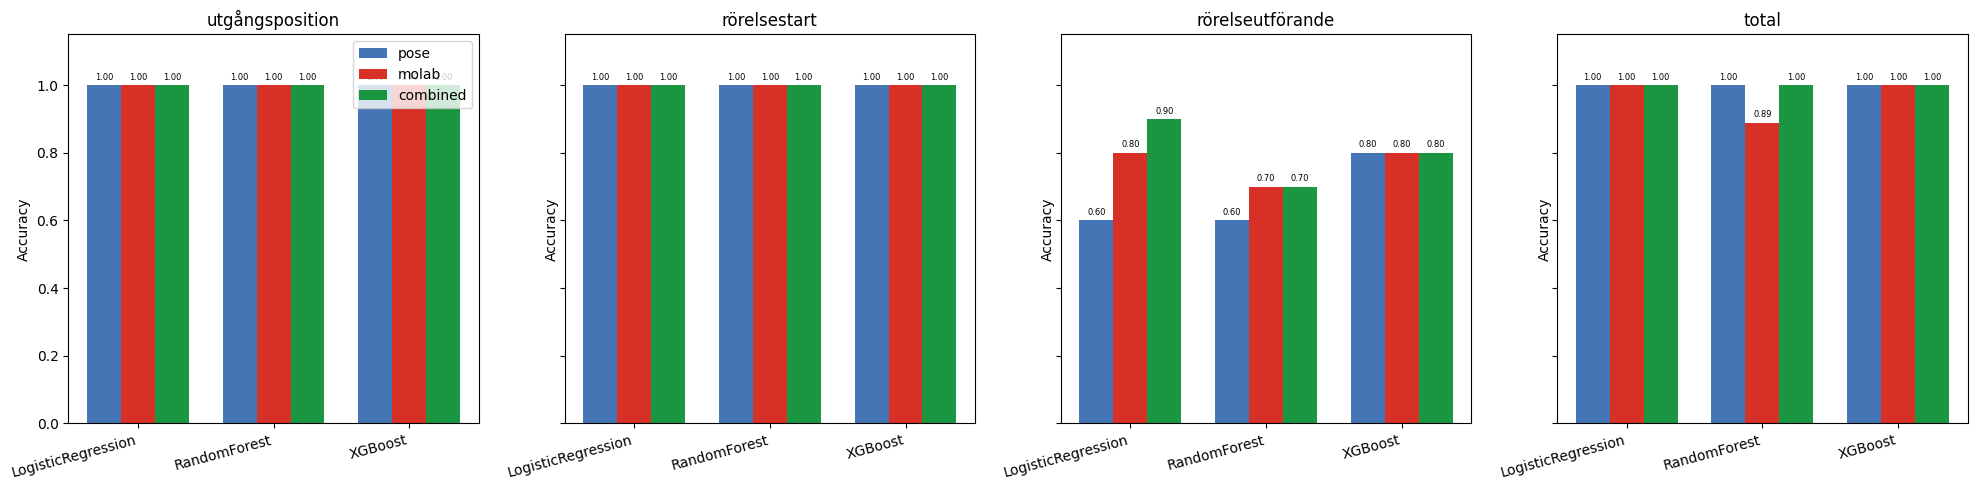

Saved: classification_accuracy_bar.png


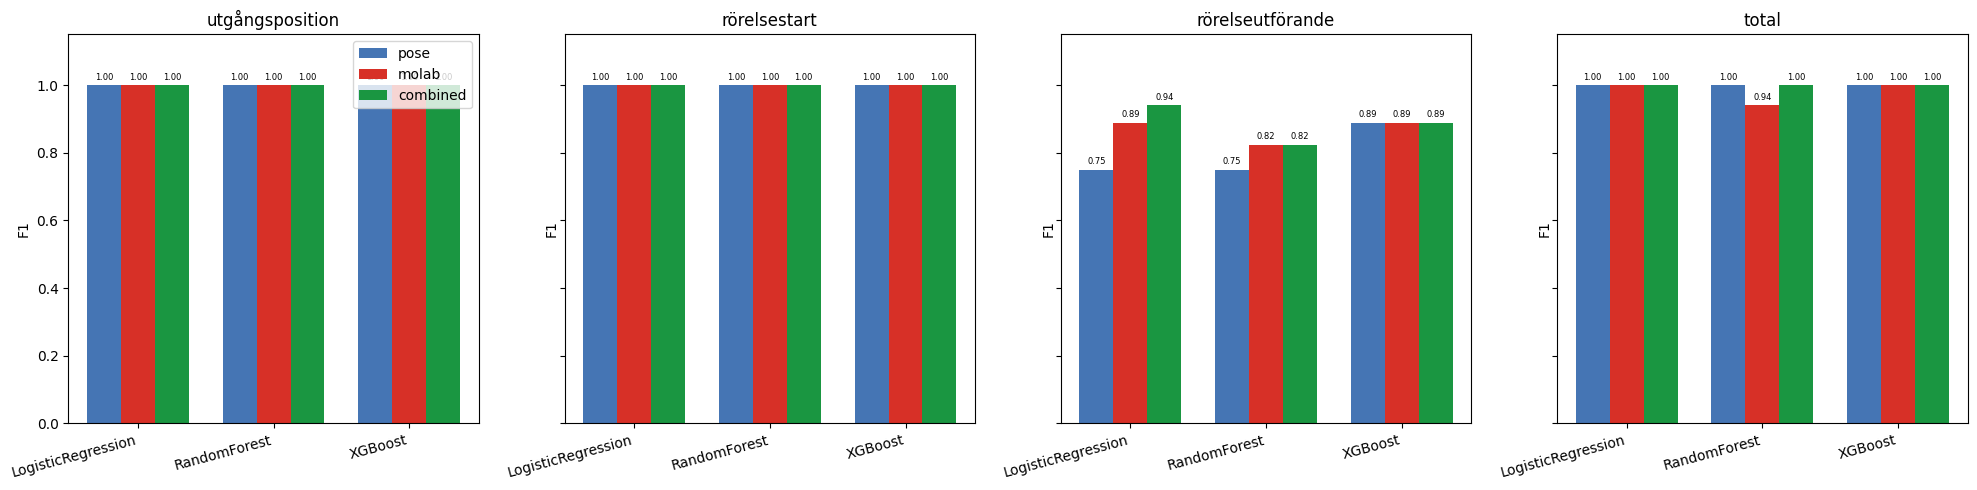

Saved: classification_f1_bar.png


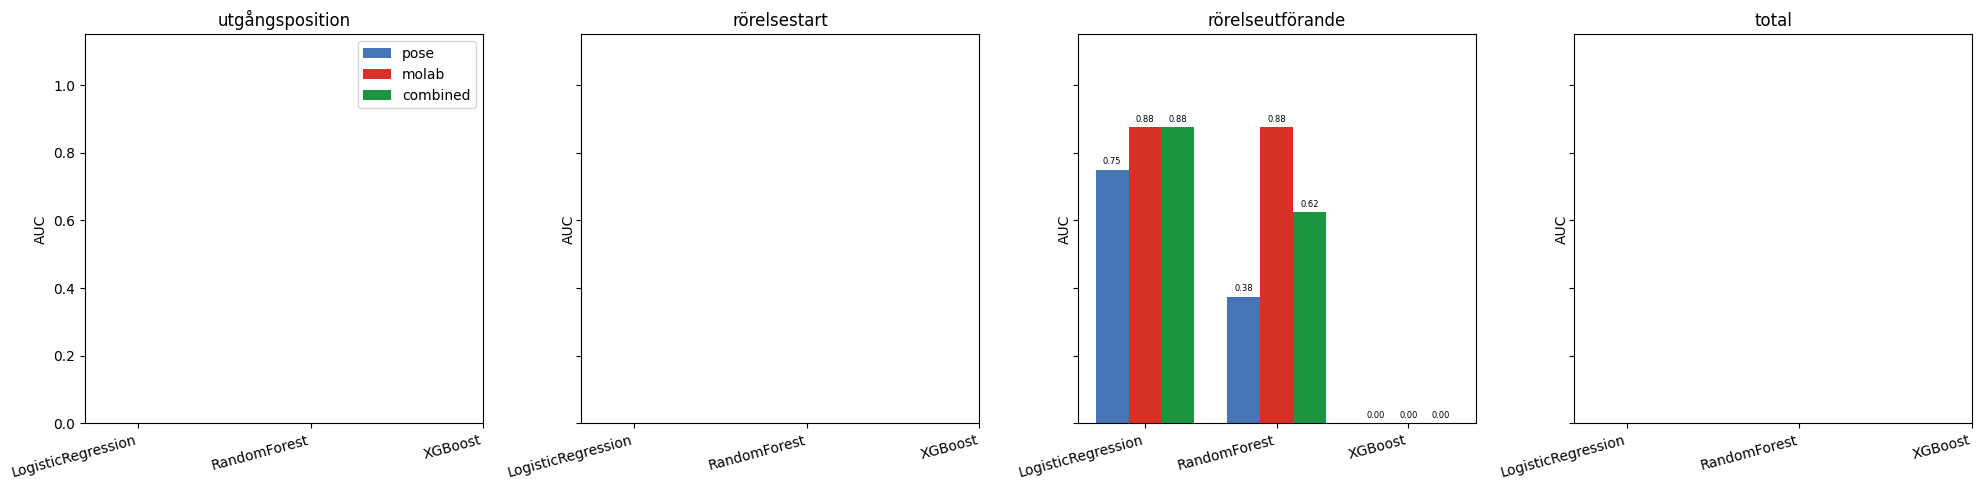

Saved: classification_auc_bar.png


In [8]:
COLORS = {'pose': '#4575b4', 'molab': '#d73027', 'combined': '#1a9641'}
PHASE_ORDER = ['utgångsposition', 'rörelsestart', 'rörelseutförande', 'total']

for metric in ['Accuracy', 'F1', 'AUC']:
    fig, axes = plt.subplots(1, len(PHASE_ORDER), figsize=(20, 5), sharey=True)
    for ax, phase in zip(axes, PHASE_ORDER):
        sub = eval_df[eval_df['phase'] == phase]
        x = np.arange(len(MODEL_ORDER))
        width = 0.25
        for i, fs in enumerate(FEATURE_SETS):
            vals = []
            for m in MODEL_ORDER:
                mask = (sub['model'] == m) & (sub['feature_set'] == fs)
                v    = sub[mask][metric].values
                vals.append(v[0] if len(v) else np.nan)
            bars = ax.bar(x + i * width, vals, width, label=fs, color=COLORS[fs])
            for bar, val in zip(bars, vals):
                if not np.isnan(val):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.01,
                        f'{val:.2f}',
                        ha='center', va='bottom', fontsize=6
                    )
        ax.set_title(phase)
        ax.set_xticks(x + width)
        ax.set_xticklabels(MODEL_ORDER, rotation=15, ha='right')
        ax.set_ylim(0, 1.15)
        ax.set_ylabel(metric)
    axes[0].legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'classification_{metric.lower()}_bar.png', dpi=150)
    plt.show()
    print(f'Saved: classification_{metric.lower()}_bar.png')


- `Rörelseutförande` shows the clearest separation between models
- The clearest benefit of `Combined` features appears in `Rörelseutförande`.

## Champion model per phase

In [9]:
METRICS = ['Accuracy', 'F1', 'AUC']

champion_rows = []
for phase in eval_df['phase'].unique():
    for fs in FEATURE_SETS:
        sub  = eval_df[(eval_df['phase'] == phase) & (eval_df['feature_set'] == fs)]
        # Fall back to Accuracy if AUC is all NaN
        if sub['AUC'].notna().any():
            best = sub.loc[sub['AUC'].idxmax()]
        else:
            best = sub.loc[sub['Accuracy'].idxmax()]
        champion_rows.append({
            'phase':       phase,
            'feature_set': fs,
            'model':       best['model'],
            'Accuracy':    round(best['Accuracy'], 3),
            'F1':          round(best['F1'],       3),
            'AUC':         round(best['AUC'], 3) if pd.notna(best['AUC']) else float('nan'),
        })

champion_df = pd.DataFrame(champion_rows)
champion_df.to_csv(OUT_DIR / 'champion_models.csv', index=False)
print(champion_df.to_string(index=False))


           phase feature_set              model  Accuracy    F1   AUC
 utgångsposition        pose LogisticRegression       1.0 1.000   NaN
 utgångsposition       molab LogisticRegression       1.0 1.000   NaN
 utgångsposition    combined LogisticRegression       1.0 1.000   NaN
    rörelsestart        pose LogisticRegression       1.0 1.000   NaN
    rörelsestart       molab LogisticRegression       1.0 1.000   NaN
    rörelsestart    combined LogisticRegression       1.0 1.000   NaN
rörelseutförande        pose LogisticRegression       0.6 0.750 0.750
rörelseutförande       molab LogisticRegression       0.8 0.889 0.875
rörelseutförande    combined LogisticRegression       0.9 0.941 0.875
           total        pose LogisticRegression       1.0 1.000   NaN
           total       molab LogisticRegression       1.0 1.000   NaN
           total    combined LogisticRegression       1.0 1.000   NaN


- `LogisticRegression` is best in `12 / 12` phase-feature combinations

## Per-video error comparison: Pose vs MoLab

In [10]:
rows = []
for r in loocv_results:
    for vid, yt, yp in zip(r['videos'], r['y_true'], r['y_pred']):
        rows.append({
            'phase':       r['phase'],
            'model':       r['model'],
            'feature_set': r['feature_set'],
            'video':       vid,
            'y_true':      yt,
            'y_pred':      yp,
        })

per_video_df = pd.DataFrame(rows)
per_video_df.to_csv(OUT_DIR / 'per_video_predictions.csv', index=False)

for phase in eval_df['phase'].unique():
    print(f"\n{'='*65}")
    print(f" Phase: {phase}")
    print(f"{'='*65}")
    for model in MODEL_ORDER:
        sub   = per_video_df[(per_video_df['phase'] == phase) & (per_video_df['model'] == model)]
        pose  = sub[sub['feature_set'] == 'pose'].set_index('video')[['y_true','y_pred']].rename(columns={'y_pred':'pose_pred'})
        molab = sub[sub['feature_set'] == 'molab'][['video','y_pred']].set_index('video').rename(columns={'y_pred':'molab_pred'})

        compare = pose.join(molab)
        compare['pose_error']  = compare['y_true'] != compare['pose_pred']
        compare['molab_error'] = compare['y_true'] != compare['molab_pred']

        diff = compare[compare['pose_error'] != compare['molab_error']]
        if diff.empty:
            continue

        print(f"\n  Model: {model}")
        print(f"  {'-'*55}")
        print(f"  {'Video':<8} {'True':>6} {'Pose':>8} {'MoLab':>8} {'Pose err':>10} {'MoLab err':>10}")
        print(f"  {'-'*55}")
        for vid, row in diff.iterrows():
            pose_err  = 'FP' if (row.pose_error  and row.pose_pred  > row.y_true) else ('FN' if row.pose_error  else '-')
            molab_err = 'FP' if (row.molab_error and row.molab_pred > row.y_true) else ('FN' if row.molab_error else '-')
            print(f"  {str(vid):<8} {int(row.y_true):>6} {int(row.pose_pred):>8} {int(row.molab_pred):>8} {pose_err:>10} {molab_err:>10}")
        print(f"  {'-'*55}")



 Phase: utgångsposition

 Phase: rörelsestart

 Phase: rörelseutförande

  Model: LogisticRegression
  -------------------------------------------------------
  Video      True     Pose    MoLab   Pose err  MoLab err
  -------------------------------------------------------
  047           1        0        1         FN          -
  061           1        0        1         FN          -
  -------------------------------------------------------

  Model: RandomForest
  -------------------------------------------------------
  Video      True     Pose    MoLab   Pose err  MoLab err
  -------------------------------------------------------
  047           1        0        1         FN          -
  061           1        0        1         FN          -
  076           1        1        0          -         FN
  -------------------------------------------------------

 Phase: total

  Model: RandomForest
  -------------------------------------------------------
  Video      True     Pos

Error comparison:
- most disagreements are isolated false negatives
- `Pose` misses videos `047` and `061` in `Rörelseutförande`
- `MoLab` also misses a few positives, such as `076` and `093`

So the errors are limited, but they are concentrated in a few videos.

## Stående till sittande (Stand-to-Sit)

In [11]:
OUT_DIR_DOWN_CLS = Path('../data/processed/classification_down')
OUT_DIR_DOWN_CLS.mkdir(parents=True, exist_ok=True)

DOWN_FEATURES_DIR_CLS = Path('../data/processed/features_down')
DOWN_SELECTED_DIR_CLS = DOWN_FEATURES_DIR_CLS / 'combined/per_video'

PHASE_MAP_DOWN_CLS = {
    'iraf_utgångsposition':  'selected_features_init.csv',
    'iraf_rörelsestart':     'selected_features_start.csv',
    'iraf_rörelseutförande': 'selected_features_execution.csv',
    'iraf_total':            'selected_features_total.csv',
}

RAK_DOWN_FP_VIDEOS_CLS = ['030', '047', '061', '076', '093']

kors_df_d, kors_pw_d = parse_iraf_per_video(kors_xl, 'Stående till sittande')
rak_df_d,  rak_pw_d  = parse_iraf_per_video(rak_xl,  'Stående till sittande', fp_videos=RAK_DOWN_FP_VIDEOS_CLS)
iraf_raw_d = pd.concat([kors_df_d, rak_df_d], ignore_index=True)
iraf_raw_d = iraf_raw_d.assign(w=iraf_raw_d['avvikelse'] * iraf_raw_d['weight'])

phase_weights_d = pd.concat([kors_pw_d, rak_pw_d]).groupby('phase')['phase_weight'].mean().to_dict()

iraf_pv_d = iraf_raw_d.groupby(['video', 'phase']).apply(
    lambda g: g['w'].sum() / g['weight'].sum()
).unstack().reset_index()
iraf_pv_d.columns.name = None
iraf_pv_d.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv_d.columns[1:]]

total_w_d = sum(phase_weights_d.values())
iraf_pv_d['iraf_total'] = sum(iraf_pv_d[f'iraf_{p}'] * w for p, w in phase_weights_d.items()) / total_w_d

iraf_bin_d = iraf_pv_d.copy()
for col in [c for c in iraf_bin_d.columns if c.startswith('iraf_')]:
    iraf_bin_d[col] = iraf_bin_d[col].apply(to_binary)
iraf_bin_d['video'] = iraf_bin_d['video'].astype(str).str.zfill(3)

iraf_bin_d


,video,iraf_rörelsestart,iraf_rörelseutförande,iraf_utgångsposition,iraf_total
0,028,0,NaN,0.0,0.0
1,030,0,0.0,0.0,0.0
2,045,0,1.0,1.0,1.0
3,047,1,NaN,NaN,1.0
4,059,0,NaN,1.0,0.0
5,061,0,0.0,1.0,0.0
6,074,1,1.0,0.0,NaN
7,076,1,0.0,1.0,1.0
8,091,0,1.0,NaN,NaN
9,093,0,1.0,1.0,1.0


In [12]:
pose_all_d = (
    pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_utgångsposition.csv')
    .merge(pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_rörelsestart.csv'),     on='video')
    .merge(pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_rörelseutförande.csv'), on='video')
)
molab_all_d = (
    pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_molab_utgångsposition.csv')
    .merge(pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_molab_rörelsestart.csv'),     on='video')
    .merge(pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_molab_rörelseutförande.csv'), on='video')
)

pose_all_d['video']  = pose_all_d['video'].astype(str).str.zfill(3)
molab_all_d['video'] = molab_all_d['video'].astype(str).str.zfill(3)
pose_all_d  = pose_all_d.rename(columns={c: f'pose_{c}'  for c in pose_all_d.columns  if c != 'video'})
molab_all_d = molab_all_d.rename(columns={c: f'molab_{c}' for c in molab_all_d.columns if c != 'video'})

phase_dfs_down_cls = {}
for target, fname in PHASE_MAP_DOWN_CLS.items():
    sel = pd.read_csv(DOWN_SELECTED_DIR_CLS / fname)
    pose_feats  = [f'pose_{f}'  for f in sel[sel['source'] == 'Pose']['feature'].tolist()]
    molab_feats = [f'molab_{f}' for f in sel[sel['source'] == 'MoLab']['feature'].tolist()]
    short = target.replace('iraf_', '')

    y_df = iraf_bin_d[['video', target]].dropna()

    pose_df  = pose_all_d[['video'] + pose_feats].merge(y_df[['video']], on='video')
    molab_df = molab_all_d[['video'] + molab_feats].merge(y_df[['video']], on='video')

    phase_dfs_down_cls[short] = {
        'pose':     pose_df,
        'molab':    molab_df,
        'combined': pose_df.merge(molab_df, on='video'),
        'y':        y_df,
    }

for phase, sources in phase_dfs_down_cls.items():
    print(f"\n{phase}: n={len(sources['y'])}, labels={sources['y'].iloc[:,1].value_counts().to_dict()}")



utgångsposition: n=8, labels={1.0: 5, 0.0: 3}

rörelsestart: n=10, labels={0: 7, 1: 3}

rörelseutförande: n=7, labels={1.0: 4, 0.0: 3}

total: n=8, labels={0.0: 4, 1.0: 4}


- some videos are excluded because scores in `0.5, 0.6` 
- the number of videos therefore differs between phases

So some phases are trained on fewer videos, which makes the results less stable


In [13]:
loocv_results_down_cls = []

for phase, data in phase_dfs_down_cls.items():
    target  = 'iraf_' + phase
    y_df    = data['y']
    videos_d  = y_df['video'].values
    y_all   = y_df[target].values.astype(int)
    for fs in FEATURE_SETS:
        merged = data[fs].merge(y_df[['video']], on='video')
        X      = merged.drop(columns='video').values
        for model_name, model in MODELS.items():
            y_true, y_pred, y_prob, vid_out = [], [], [], []
            for train_idx, test_idx in loo.split(X):
                X_train, X_test = X[train_idx], X[test_idx]
                y_train = y_all[train_idx]
                if len(np.unique(y_train)) < 2:
                    continue
                scaler  = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test  = scaler.transform(X_test)
                m = clone(model)
                m.fit(X_train, y_train)
                y_true.append(y_all[test_idx][0])
                y_pred.append(m.predict(X_test)[0])
                prob    = m.predict_proba(X_test)[0]
                pos_idx = list(m.classes_).index(1) if 1 in m.classes_ else 0
                y_prob.append(prob[pos_idx])
                vid_out.append(videos_d[test_idx][0])
            loocv_results_down_cls.append({
                'phase':       phase,
                'model':       model_name,
                'feature_set': fs,
                'videos':      vid_out,
                'y_true':      y_true,
                'y_pred':      y_pred,
                'y_prob':      y_prob,
            })

print(f'Completed: {len(loocv_results_down_cls)} models trained')


Completed: 36 models trained


LOOCV finished:
- `36 = 4 × 3 × 3`
- `4` phases
- `3` feature sets
- `3` models

So all stand-to-sit model configurations were trained.

In [14]:
rows_d = []
for r in loocv_results_down_cls:
    yt, yp, ypr = r['y_true'], r['y_pred'], r['y_prob']
    n_classes = len(set(yt))
    rows_d.append({
        'phase':       r['phase'],
        'model':       r['model'],
        'feature_set': r['feature_set'],
        'Accuracy':    accuracy_score(yt, yp),
        'F1':          f1_score(yt, yp, zero_division=0),
        'Precision':   precision_score(yt, yp, zero_division=0),
        'Recall':      recall_score(yt, yp, zero_division=0),
        'AUC':         roc_auc_score(yt, ypr) if n_classes > 1 else np.nan,
    })

eval_df_down_cls = pd.DataFrame(rows_d)
eval_df_down_cls.to_csv(OUT_DIR_DOWN_CLS / 'classification_results.csv', index=False)

METRICS_D = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC']

for phase in eval_df_down_cls['phase'].unique():
    print(f"\nPhase: {phase}")
    sub   = eval_df_down_cls[eval_df_down_cls['phase'] == phase].copy()
    table = sub.pivot_table(index='model', columns='feature_set', values=METRICS_D).round(3)
    table.columns = [f'{metric}_{fs}' for metric, fs in table.columns]
    print(table.to_string())
    print()



Phase: utgångsposition
                    AUC_combined  AUC_molab  AUC_pose  Accuracy_combined  Accuracy_molab  Accuracy_pose  F1_combined  F1_molab  F1_pose  Precision_combined  Precision_molab  Precision_pose  Recall_combined  Recall_molab  Recall_pose
model                                                                                                                                                                                                                                   
LogisticRegression         0.867      0.667     0.933              0.750           0.625          0.875        0.800     0.667    0.909               0.800            0.750           0.833              0.8           0.6          1.0
RandomForest               0.667      0.633     0.867              0.750           0.625          0.750        0.800     0.667    0.800               0.800            0.750           0.800              0.8           0.6          0.8
XGBoost                    0.000      0.000 

- `LogisticRegression` is the most consistent model
- `Pose` is strongest for `Utgångsposition` and `Rörelsestart`
- `MoLab` and `Combined` are strongest for `Total`
- `XGBoost` is unstable in several phases

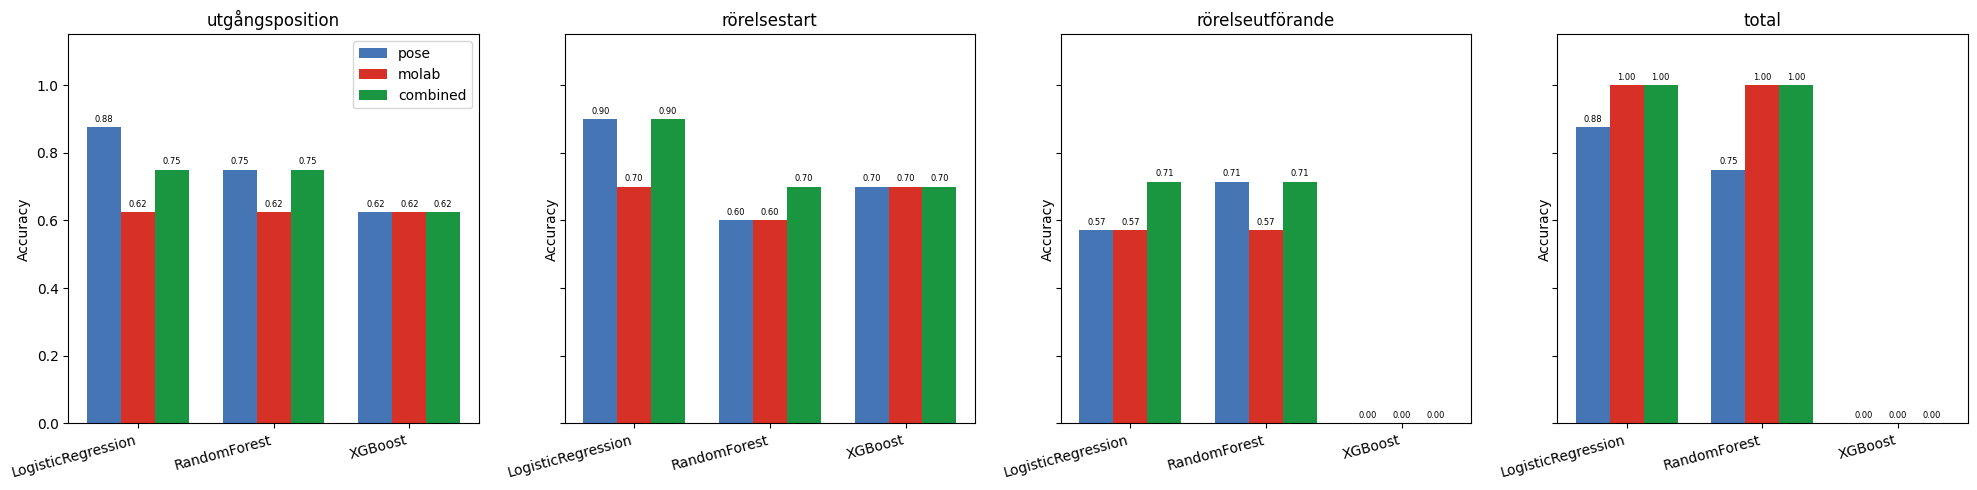

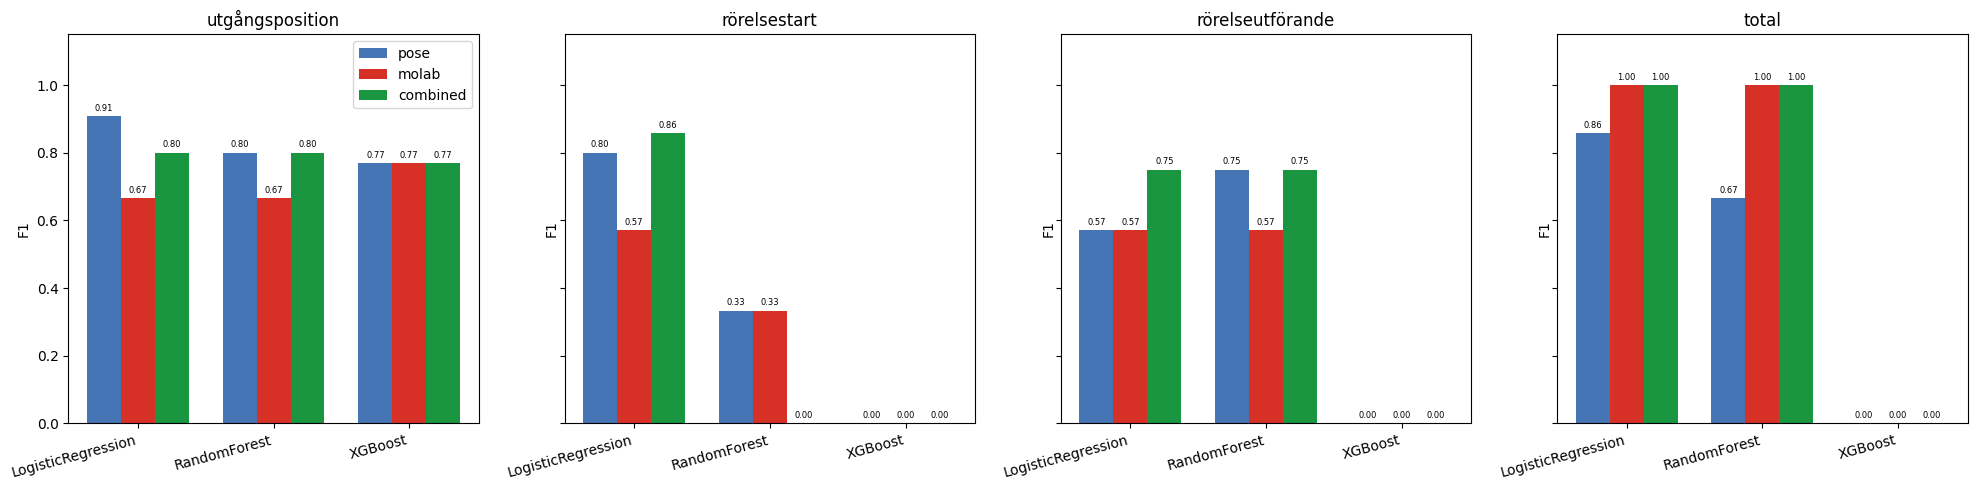

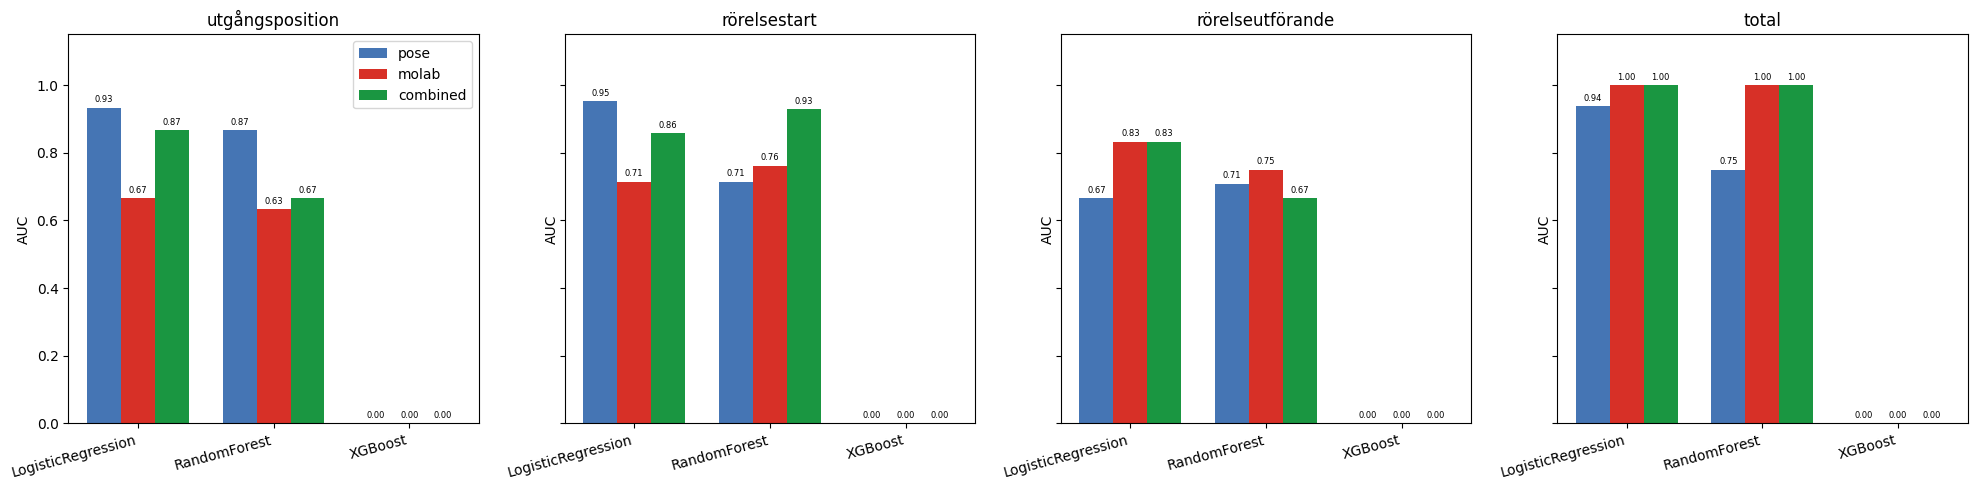

In [15]:
COLORS_D = {'pose': '#4575b4', 'molab': '#d73027', 'combined': '#1a9641'}
PHASE_ORDER_DOWN_CLS = list(phase_dfs_down_cls.keys())

for metric in ['Accuracy', 'F1', 'AUC']:
    fig, axes = plt.subplots(1, len(PHASE_ORDER_DOWN_CLS), figsize=(20, 5), sharey=True)
    for ax, phase in zip(axes, PHASE_ORDER_DOWN_CLS):
        sub = eval_df_down_cls[eval_df_down_cls['phase'] == phase]
        x = np.arange(len(MODEL_ORDER))
        width = 0.25
        for i, fs in enumerate(FEATURE_SETS):
            vals = []
            for m in MODEL_ORDER:
                mask = (sub['model'] == m) & (sub['feature_set'] == fs)
                v    = sub[mask][metric].values
                vals.append(v[0] if len(v) else np.nan)
            bars = ax.bar(x + i * width, vals, width, label=fs, color=COLORS_D[fs])
            for bar, val in zip(bars, vals):
                if not np.isnan(val):
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                            f'{val:.2f}', ha='center', va='bottom', fontsize=6)
        ax.set_title(phase)
        ax.set_xticks(x + width)
        ax.set_xticklabels(MODEL_ORDER, rotation=15, ha='right')
        ax.set_ylim(0, 1.15)
        ax.set_ylabel(metric)
    axes[0].legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR_DOWN_CLS / f'classification_{metric.lower()}_bar.png', dpi=150)
    plt.show()


In [16]:
mcnemar_rows_d = []

model_pairs = [
    ('LogisticRegression', 'RandomForest'),
    ('LogisticRegression', 'XGBoost'),
    ('RandomForest',       'XGBoost'),
]

for phase in eval_df_down_cls['phase'].unique():
    for fs in FEATURE_SETS:
        for m1, m2 in model_pairs:
            r1 = next(r for r in loocv_results_down_cls
                      if r['phase'] == phase and r['model'] == m1 and r['feature_set'] == fs)
            r2 = next(r for r in loocv_results_down_cls
                      if r['phase'] == phase and r['model'] == m2 and r['feature_set'] == fs)
            yt = np.array(r1['y_true'])
            p1 = np.array(r1['y_pred'])
            p2 = np.array(r2['y_pred'])
            b = np.sum((p1 == yt) & (p2 != yt))
            c = np.sum((p1 != yt) & (p2 == yt))
            table = [[np.sum((p1 == yt) & (p2 == yt)), b],
                     [c, np.sum((p1 != yt) & (p2 != yt))]]
            result = mcnemar(table, exact=True)
            mcnemar_rows_d.append({
                'phase':       phase,
                'feature_set': fs,
                'model_1':     m1,
                'model_2':     m2,
                'b':           b,
                'c':           c,
                'p_value':     result.pvalue,
                'significant': result.pvalue < 0.05,
            })

mcnemar_df_d = pd.DataFrame(mcnemar_rows_d)
mcnemar_df_d.to_csv(OUT_DIR_DOWN_CLS / 'mcnemar_results.csv', index=False)

print(mcnemar_df_d[['phase','feature_set','model_1','model_2','p_value','significant']].to_string(index=False))


           phase feature_set            model_1      model_2  p_value  significant
 utgångsposition        pose LogisticRegression RandomForest 1.000000        False
 utgångsposition        pose LogisticRegression      XGBoost 0.500000        False
 utgångsposition        pose       RandomForest      XGBoost 1.000000        False
 utgångsposition       molab LogisticRegression RandomForest 1.000000        False
 utgångsposition       molab LogisticRegression      XGBoost 1.000000        False
 utgångsposition       molab       RandomForest      XGBoost 1.000000        False
 utgångsposition    combined LogisticRegression RandomForest 1.000000        False
 utgångsposition    combined LogisticRegression      XGBoost 1.000000        False
 utgångsposition    combined       RandomForest      XGBoost 1.000000        False
    rörelsestart        pose LogisticRegression RandomForest 0.250000        False
    rörelsestart        pose LogisticRegression      XGBoost 0.500000        False
    

- At the `phase level` most comparisons are not significant.
- The clearest differences are observed at the `total level`, indicating a `statistically significant gap`.
- `Logistic Regression` and `Random Forest` show similar performance

In [17]:
rows_pv_d = []
for r in loocv_results_down_cls:
    for vid, yt, yp in zip(r['videos'], r['y_true'], r['y_pred']):
        rows_pv_d.append({
            'phase':       r['phase'],
            'model':       r['model'],
            'feature_set': r['feature_set'],
            'video':       vid,
            'y_true':      yt,
            'y_pred':      yp,
        })

per_video_df_d = pd.DataFrame(rows_pv_d)
per_video_df_d.to_csv(OUT_DIR_DOWN_CLS / 'per_video_predictions.csv', index=False)

for phase in eval_df_down_cls['phase'].unique():
    print(f"\n{'='*65}")
    print(f" Phase: {phase}")
    print(f"{'='*65}")
    for model in MODEL_ORDER:
        sub   = per_video_df_d[(per_video_df_d['phase'] == phase) & (per_video_df_d['model'] == model)]
        pose  = sub[sub['feature_set'] == 'pose'].set_index('video')[['y_true','y_pred']].rename(columns={'y_pred':'pose_pred'})
        molab = sub[sub['feature_set'] == 'molab'][['video','y_pred']].set_index('video').rename(columns={'y_pred':'molab_pred'})

        compare = pose.join(molab)
        compare['pose_error']  = compare['y_true'] != compare['pose_pred']
        compare['molab_error'] = compare['y_true'] != compare['molab_pred']

        diff = compare[compare['pose_error'] != compare['molab_error']]
        if diff.empty:
            continue

        print(f"\n  Model: {model}")
        print(f"  {'-'*55}")
        print(f"  {'Video':<8} {'True':>6} {'Pose':>8} {'MoLab':>8} {'Pose err':>10} {'MoLab err':>10}")
        print(f"  {'-'*55}")
        for vid, row in diff.iterrows():
            pose_err  = 'FP' if (row.pose_error  and row.pose_pred  > row.y_true) else ('FN' if row.pose_error  else '-')
            molab_err = 'FP' if (row.molab_error and row.molab_pred > row.y_true) else ('FN' if row.molab_error else '-')
            print(f"  {str(vid):<8} {int(row.y_true):>6} {int(row.pose_pred):>8} {int(row.molab_pred):>8} {pose_err:>10} {molab_err:>10}")
        print(f"  {'-'*55}")



 Phase: utgångsposition

  Model: LogisticRegression
  -------------------------------------------------------
  Video      True     Pose    MoLab   Pose err  MoLab err
  -------------------------------------------------------
  059           1        1        0          -         FN
  093           1        1        0          -         FN
  -------------------------------------------------------

  Model: RandomForest
  -------------------------------------------------------
  Video      True     Pose    MoLab   Pose err  MoLab err
  -------------------------------------------------------
  045           1        0        1         FN          -
  059           1        1        0          -         FN
  093           1        1        0          -         FN
  -------------------------------------------------------

 Phase: rörelsestart

  Model: LogisticRegression
  -------------------------------------------------------
  Video      True     Pose    MoLab   Pose err  MoLab err
  

Error comparison:
- `MoLab` misses several positives in `Utgångsposition` and `Total`
- `Pose` makes both false positives and false negatives in `Rörelsestart`

In [18]:
champion_rows_d = []
for phase in eval_df_down_cls['phase'].unique():
    for fs in FEATURE_SETS:
        sub  = eval_df_down_cls[(eval_df_down_cls['phase'] == phase) & (eval_df_down_cls['feature_set'] == fs)]
        if sub['AUC'].notna().any():
            best = sub.loc[sub['AUC'].idxmax()]
        else:
            best = sub.loc[sub['Accuracy'].idxmax()]
        champion_rows_d.append({
            'phase':       phase,
            'feature_set': fs,
            'model':       best['model'],
            'Accuracy':    round(best['Accuracy'], 3),
            'F1':          round(best['F1'],       3),
            'AUC':         round(best['AUC'], 3) if pd.notna(best['AUC']) else float('nan'),
        })

champion_df_down = pd.DataFrame(champion_rows_d)
champion_df_down.to_csv(OUT_DIR_DOWN_CLS / 'champion_models.csv', index=False)
print(champion_df_down.to_string(index=False))


           phase feature_set              model  Accuracy    F1   AUC
 utgångsposition        pose LogisticRegression     0.875 0.909 0.933
 utgångsposition       molab LogisticRegression     0.625 0.667 0.667
 utgångsposition    combined LogisticRegression     0.750 0.800 0.867
    rörelsestart        pose LogisticRegression     0.900 0.800 0.952
    rörelsestart       molab       RandomForest     0.600 0.333 0.762
    rörelsestart    combined       RandomForest     0.700 0.000 0.929
rörelseutförande        pose       RandomForest     0.714 0.750 0.708
rörelseutförande       molab LogisticRegression     0.571 0.571 0.833
rörelseutförande    combined LogisticRegression     0.714 0.750 0.833
           total        pose LogisticRegression     0.875 0.857 0.938
           total       molab LogisticRegression     1.000 1.000 1.000
           total    combined LogisticRegression     1.000 1.000 1.000


- `LogisticRegression` is best in `10 / 12` combinations
- `RandomForest` leads only for `MoLab / Rörelsestart` and `Pose / Rörelseutförande`

So `LogisticRegression` is the main stand-to-sit winner.